# Data analisi su rapporto studenti-studio

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(f'pandas     : {pd.__version__}')
print(f'numpy      : {np.__version__}')
print(f'matplotlib : {plt.matplotlib.__version__}')

pandas     : 3.0.2
numpy      : 2.4.4
matplotlib : 3.10.8


In [2]:
df = pd.read_csv('studenti_studio.csv')

df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   metodo_studio  200 non-null    str    
 1   rendimento     200 non-null    str    
 2   ore_studio     200 non-null    float64
 3   dispositivo    200 non-null    str    
 4   sesso          200 non-null    str    
dtypes: float64(1), str(4)
memory usage: 7.9 KB


,ore_studio
count,200.000000
mean,7.854500
std,2.964426
min,1.000000
25%,5.875000
50%,7.850000
75%,9.625000
max,15.800000


In [3]:
df.head(10)
df.tail(10)

,metodo_studio,rendimento,ore_studio,dispositivo,sesso
190,Gruppo,Medio,12.0,Tablet,M
191,Appunti,Basso,11.7,Tablet,M
192,Appunti,Medio,7.2,PC,M
193,Libro,Alto,9.1,Smartphone,M
194,Appunti,Basso,1.0,Tablet,M
195,Appunti,Medio,4.5,PC,F
196,Video,Alto,7.1,PC,M
197,Gruppo,Basso,4.8,Tablet,F
198,Appunti,Medio,10.1,PC,M
199,Appunti,Medio,14.0,Tablet,F


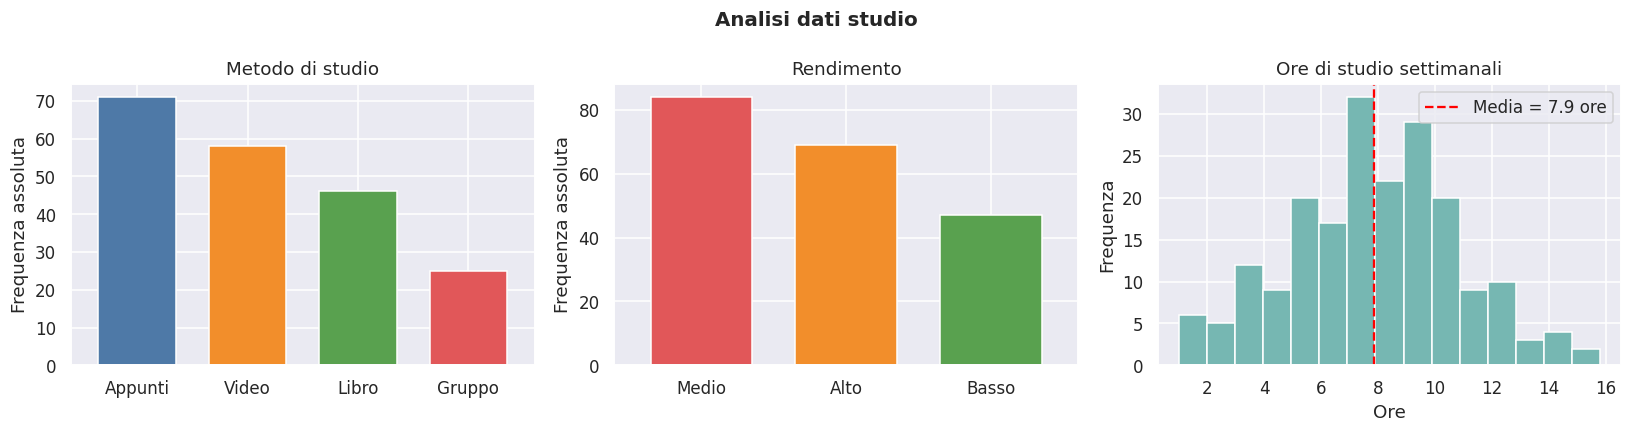

In [8]:
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'monospace'
sns.set_theme(style="darkgrid", palette='muted')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Analisi dati studio', fontsize=13, fontweight='bold')

# 1° grafico
colori_metodi = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']
df['metodo_studio'].value_counts().plot(
    kind="bar", ax=axes[0], color=colori_metodi, edgecolor='white', width=0.7
)
axes[0].set_title('Metodo di studio')
axes[0].set_xlabel('')
axes[0].set_ylabel('Frequenza assoluta')
axes[0].tick_params(axis='x', rotation=0)

# 2° grafico
colori_rendimento = ['#e15759', '#f28e2b', '#59a14f']
df['rendimento'].value_counts().plot(
    kind="bar", ax=axes[1], color=colori_rendimento, edgecolor='white', width=0.7
)
axes[1].set_title('Rendimento')
axes[1].set_xlabel('')
axes[1].set_ylabel('Frequenza assoluta')
axes[1].tick_params(axis='x', rotation=0)

axes[2].hist(df['ore_studio'], bins=15, color="#76b7b2", edgecolor="white")
axes[2].axvline(df['ore_studio'].mean(), color="red", linestyle="--", 
                label=f'Media = {df['ore_studio'].mean():.1f} ore')
axes[2].set_title('Ore di studio settimanali')
axes[2].set_xlabel('Ore')
axes[2].set_ylabel('Frequenza')
axes[2].legend()


plt.tight_layout()
plt.show()


## Tabella di Contingenza
Visualizziamo una tabella che mostra le frequenze osservato per ciascuna combinazione delle due categorie scelte

In [9]:
tab_frequenze_osservate = pd.crosstab(
    df['metodo_studio'],
    df['rendimento'],
    margins = True,
    margins_name = 'TOT'
)
tab_frequenze_osservate

rendimento,Alto,Basso,Medio,TOT
metodo_studio,,,,
Appunti,23,15,33,71
Gruppo,4,11,10,25
Libro,24,4,18,46
Video,18,17,23,58
TOT,69,47,84,200


In [10]:
tab_percentuali_riga = pd.crosstab(
    df['metodo_studio'],
    df['rendimento'],
    normalize='index'
).mul(100).round(1)
tab_percentuali_riga

rendimento,Alto,Basso,Medio
metodo_studio,,,
Appunti,32.4,21.1,46.5
Gruppo,16.0,44.0,40.0
Libro,52.2,8.7,39.1
Video,31.0,29.3,39.7


## Test del chi quadro

Calcolare la tabella delle frequenze attese

In [11]:
tabella_senza_margini = pd.crosstab(
    df['metodo_studio'],
    df['rendimento']
)
tabella_senza_margini

rendimento,Alto,Basso,Medio
metodo_studio,,,
Appunti,23,15,33
Gruppo,4,11,10
Libro,24,4,18
Video,18,17,23


In [16]:
N = tabella_senza_margini.values.sum()
totali_riga = tabella_senza_margini.sum(axis=1)
totali_colonna = tabella_senza_margini.sum(axis=0)

matrice_frequenze_attese = np.outer(totali_riga, totali_colonna) / N

tabella_frequenze_attese = pd.DataFrame(matrice_frequenze_attese, index=tabella_senza_margini.index,
                                        columns=tabella_senza_margini.columns)
tabella_frequenze_attese

rendimento,Alto,Basso,Medio
metodo_studio,,,
Appunti,24.495,16.685,29.82
Gruppo,8.625,5.875,10.50
Libro,15.870,10.810,19.32
Video,20.010,13.630,24.36


In [20]:
frequenze_osservate = tabella_senza_margini.values.astype(float)
frequenze_attese = tabella_frequenze_attese.values

contributo_ogni_cella = (frequenze_osservate - frequenze_attese)**2 / frequenze_attese

chi_quadrato = contributo_ogni_cella.sum()
chi_quadrato

np.float64(17.23140515057321)